# SDG&E Electric Grid Polyon to Lines

SDG&E electric grid data is in polygon format when downloaded. This is different from the electric grid data acquired from SCE and PG&E which is in line format. This notebook creates line data from the polygon data. 

In [42]:
# load necessary libraries
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box  # To create polygon bounding box
import glob
import os
import folium # for the interactive map
import pygeoops # to get the centerline of the polygons

# Connecting the Polygons

To riterate this analysis is relying on feeder line data. SDG&E holds feeder line data in polygons. We'll use `GeoPandas` `dissolve()` function to aggregate the polygons based on the `LINE_SEGMENT_NUMBER`. Geospatially, the load and generation capacity maps are the same but the values are different across the two layers. This analysis will be completed for both the load and generation capacity layers. 

In [43]:
# load SDGE generation capacity data
sdge_generation_capacity = gpd.read_file("../../../../capstone/electrigrid/data/utilities/sandiego_grid/ICA_MAP_PROD_GenerationCapacityGrids.geojson")

The unique values are down to the `LINE_SEGMENT_NUMBER` layer so we need to ensure that all of this data is maintained. Checking the number of unique values at each level acts as a confirmation that the information is being maintained. 

In [44]:
# check how many values there are of each different column
print(len(list(sdge_generation_capacity['LINE_SEGMENT_NUMBER'].unique())))
print(len(list(sdge_generation_capacity['CIRCUIT_NAME'].unique())))
print(len(list(sdge_generation_capacity['SUBID'].unique())))

144658
645
104


In [46]:
# view the dataframe
sdge_generation_capacity.head()

,OBJECTID,VOLTAGE,LINE_SEGMENT_NUMBER,ICAWOF_UNIGENERATION,ICAWOF_UNILOAD,ICAWOF_PVGENERATION,OHUG,CIRCUIT_NAME,LABELTEXT,ICAWNOF_UNIGENERATION,ICAWNOF_UNILOAD,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,SUBID,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,geometry
0,32500971,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"POLYGON ((-117.51529 33.39328, -117.51529 33.3..."
1,32500972,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"POLYGON ((-117.51529 33.39294, -117.51529 33.3..."
2,32500973,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"POLYGON ((-117.51611 33.39362, -117.51611 33.3..."
3,32500974,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"POLYGON ((-117.51611 33.39328, -117.51611 33.3..."
4,32500975,12,846583,0.0,3.0,0.2,OH,204,None,0.1,3.0,0.7,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"POLYGON ((-117.55531 33.37352, -117.55532 33.3..."


# Utilize `pygeoops.centerline` to get centerlines

Calculate the centerlines with pygeoops.

**Note:** This takes just under ten minutes to run. 


In [47]:
sdge_generation_capacity.geometry = pygeoops.centerline(sdge_generation_capacity.geometry)

# after your script is done:
os.system('say "Your script has finished!"')

In [48]:
sdge_generation_capacity.head()

,OBJECTID,VOLTAGE,LINE_SEGMENT_NUMBER,ICAWOF_UNIGENERATION,ICAWOF_UNILOAD,ICAWOF_PVGENERATION,OHUG,CIRCUIT_NAME,LABELTEXT,ICAWNOF_UNIGENERATION,ICAWNOF_UNILOAD,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,SUBID,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,geometry
0,32500971,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (-117.51510 33.39346, -117.51466 33..."
1,32500972,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (-117.51510 33.39311, -117.51466 33..."
2,32500973,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (-117.51592 33.39380, -117.51548 33..."
3,32500974,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (-117.51592 33.39345, -117.51548 33..."
4,32500975,12,846583,0.0,3.0,0.2,OH,204,None,0.1,3.0,0.7,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (-117.55512 33.37370, -117.55469 33..."


Make sure that the granularity of the data is maintained. 

In [54]:
# check how many values there are of each different column
print(len(list(sdge_generation_capacity['LINE_SEGMENT_NUMBER'].unique())))
print(len(list(sdge_generation_capacity['CIRCUIT_NAME'].unique())))
print(len(list(sdge_generation_capacity['SUBID'].unique())))

144658
645
104


## Plot the line segment data
Visualize the change from polygons to lines of the `LINE_SEGMENT_NUMBER`.

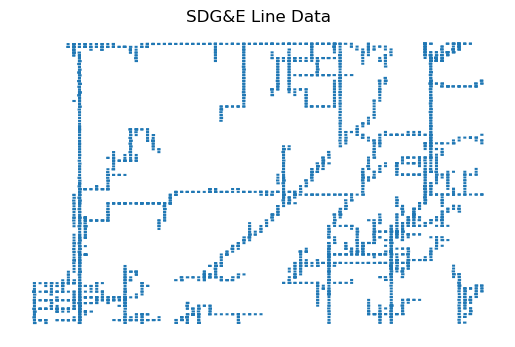

In [50]:
# make a bbox to get a closer look
sd_bbox = box(-117.136541,32.713699,-117.071653,32.747959)

# use the San Diego bbox to make better analyze the findings
sd_sub_gen_capacity = gpd.clip(sdge_generation_capacity, sd_bbox)

# plot the subset of load gen differences
fig, ax = plt.subplots()

sd_sub_gen_capacity.plot(ax=ax)

ax.set_title('SDG&E Line Data')
ax.axis('off')

plt.show()

Save the centerlines for use in later analysis. The next code chunk saves it directly to the directory where the file is being run. It has been downloaded and added to the capstone data folder on workbench 2. It is commented out to avoid git issues from accidentally attempting to push large amounts of data.

In [ ]:
# output_shapefile_path = 'gen_cap_lines_sdge.geojson'

# sdge_generation_capacity.to_file(output_shapefile_path)

In [ ]:
# read in the new file to make sure it worked
gen_line_sdge = gpd.read_file("gen_cap_lines_sdge.geojson")

# view the new data frame
gen_line_sdge.head()

,OBJECTID,VOLTAGE,LINE_SEGMENT_NUMBER,ICAWOF_UNIGENERATION,ICAWOF_UNILOAD,ICAWOF_PVGENERATION,OHUG,CIRCUIT_NAME,LABELTEXT,ICAWNOF_UNIGENERATION,ICAWNOF_UNILOAD,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,SUBID,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,geometry
0,32500971,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (-117.51510 33.39346, -117.51466 33..."
1,32500972,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (-117.51510 33.39311, -117.51466 33..."
2,32500973,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (-117.51592 33.39380, -117.51548 33..."
3,32500974,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (-117.51592 33.39345, -117.51548 33..."
4,32500975,12,846583,0.0,3.0,0.2,OH,204,None,0.1,3.0,0.7,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (-117.55512 33.37370, -117.55469 33..."


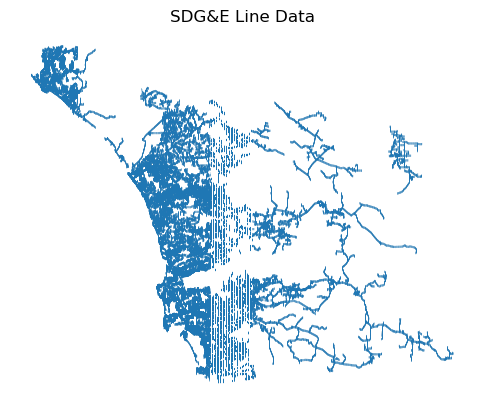

In [ ]:
# plot the line data to ensure its all there
fig, ax = plt.subplots()
gen_line_sdge. plot (ax=ax)
ax. set_title('SDG&E Generation Line Data')
ax.axis('off') 
plt. show()

# Replicate the above with the load hosting capacity

Save the centerlines for use in later analysis. The next code chunk saves load capacity lines directly to the directory where the file is being run. It has been downloaded and added to the capstone data folder on workbench 2. It is commented out to avoid git issues from accidentally attempting to push large amounts of data.

In [ ]:
# # load SDGE generation capacity data
# sdge_load_capacity = gpd.read_file("../../../../capstone/electrigrid/data/utilities/sandiego_grid/ICA_MAP_PROD_LoadCapacityGrids.geojson")

# # calculate the center lines for each of the polygons
# sdge_load_capacity.geometry = pygeoops.centerline(sdge_load_capacity.geometry)

# output_shapefile_path = 'load_cap_lines_sdge.geojson'

# sdge_load_capacity.to_file(output_shapefile_path)


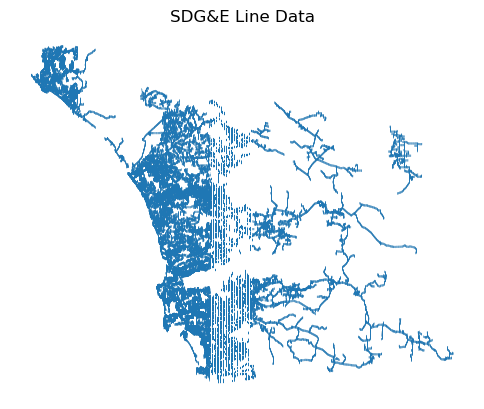

In [59]:
# read in the new file to make sure it worked
load_line_sdge = gpd.read_file("load_cap_lines_sdge.geojson")

# view the new data frame
load_line_sdge.head()

# plot the line data to ensure its all there
fig, ax = plt.subplots()
load_line_sdge. plot (ax=ax)
ax. set_title('SDG&E Load Line Data')
ax.axis('off') 
plt. show()

The lines through the different maps in the same place in both maps is perlexing. This will take some investigation. 